# Flood Image Detection with SegFormer Experiments 1-4

This notebook implements a **SegFormer-based semantic segmentation pipeline** aligned with the project goal of identifying flooded regions from post-disaster aerial imagery.

This notebook utilizes the following parameters:
- {"epochs": 20, "lr": 5e-5, "weight_decay": 1e-4},
- {"epochs": 20, "lr": 3e-5, "weight_decay": 1e-4},
- {"epochs": 20, "lr": 3e-5, "weight_decay": 1e-2},
- {"epochs": 30, "lr": 1e-5, "weight_decay": 1e-2},

It follows the project document by:
- using the **FloodNet-style split structure** (`train`, `val`, `test`)
- focusing on the flood-relevant classes:
  - `1 = Building Flooded`
  - `3 = Road Flooded`
  - `5 = Water`
- converting the original multi-class masks into a **binary flood vs. non-flood segmentation task**
- evaluating the model with **pixel accuracy, precision, recall, F1, and IoU**

The notebook is written so you can run it locally or in Colab/Jupyter after downloading the dataset folder.

## 1. Environment setup

This notebook uses Hugging Face Transformers' SegFormer implementation. The official Transformers documentation describes SegFormer as a hierarchical Transformer encoder with a lightweight decoder for semantic segmentation, and the semantic segmentation task guide documents the general fine-tuning workflow. citeturn144765search1turn144765search3

In [14]:

# If you are in a fresh notebook environment, uncomment this:
# !pip install -q transformers accelerate evaluate datasets gdown albumentations opencv-python pillow matplotlib pandas scikit-learn tqdm

In [15]:

import os
import random
import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation

In [16]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Download or point to the dataset

Use the Google Drive folder you provided. If the folder is public, `gdown` can often download it directly. Otherwise, download it manually and set `DATASET_ROOT` to the local folder.

In [17]:
DATASET_ROOT = Path("../data/flood_dataset")

## 3. Expected folder structure

This notebook tries to automatically detect a common split layout such as:

```text
flood_dataset/
    train/
        image/ or images/
        mask/ or masks/
    val/
        image/ or images/
        mask/ or masks/
    test/
        image/ or images/
        mask/ or masks/
```

If your exact folder names differ, update the helper function below.

In [18]:
from pathlib import Path
import pandas as pd

def list_image_files(folder):
    exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
    return sorted([p for p in folder.glob("*") if p.suffix.lower() in exts])

def match_image_mask_pairs(image_dir, mask_dir, split_name, group_name):
    rows = []

    image_files = list_image_files(image_dir)
    mask_files = list_image_files(mask_dir)

    # FloodNet masks appear to use image_stem + "_lab"
    mask_lookup = {m.stem: m for m in mask_files}

    matched = 0
    for img_path in image_files:
        img_stem = img_path.stem
        possible_keys = [img_stem, f"{img_stem}_lab"]

        mask_path = None
        for key in possible_keys:
            if key in mask_lookup:
                mask_path = mask_lookup[key]
                break

        if mask_path is not None:
            rows.append({
                "split": split_name,
                "group": group_name,
                "image_path": str(img_path),
                "mask_path": str(mask_path),
                "id": img_stem,
            })
            matched += 1

    print(f"{split_name}/{group_name}: matched {matched} image-mask pairs")
    return rows

def build_split_dataframe(dataset_root):
    dataset_root = Path(dataset_root)
    rows = []

    train_labeled = dataset_root / "Train" / "Labeled"

    flooded_img_dir = train_labeled / "Flooded" / "image"
    flooded_mask_dir = train_labeled / "Flooded" / "mask"
    nonflooded_img_dir = train_labeled / "Non-Flooded" / "image"
    nonflooded_mask_dir = train_labeled / "Non-Flooded" / "mask"

    if flooded_img_dir.exists() and flooded_mask_dir.exists():
        rows.extend(match_image_mask_pairs(flooded_img_dir, flooded_mask_dir, "train", "Flooded"))

    if nonflooded_img_dir.exists() and nonflooded_mask_dir.exists():
        rows.extend(match_image_mask_pairs(nonflooded_img_dir, nonflooded_mask_dir, "train", "Non-Flooded"))

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("No image-mask pairs were found. Check DATASET_ROOT and folder names.")

    return df

df = build_split_dataframe(DATASET_ROOT)
df.head()

train/Flooded: matched 51 image-mask pairs
train/Non-Flooded: matched 347 image-mask pairs


,split,group,image_path,mask_path,id
0,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,10165
1,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,10166
2,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,6279
3,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,6614
4,train,Flooded,..\data\flood_dataset\Train\Labeled\Flooded\im...,..\data\flood_dataset\Train\Labeled\Flooded\ma...,6615


In [19]:
print(df["split"].value_counts())
print(df["group"].value_counts())
print(len(df))

split
train    398
Name: count, dtype: int64
group
Non-Flooded    347
Flooded         51
Name: count, dtype: int64
398


In [20]:

print("Dataset shape:", df.shape)
display(df["split"].value_counts())

Dataset shape: (398, 5)


split
train    398
Name: count, dtype: int64

## 4. Class definitions and binary flood mapping

The project document lists these original semantic classes:

- 0 Background
- 1 Building Flooded
- 2 Building Non-Flooded
- 3 Road Flooded
- 4 Road Non-Flooded
- 5 Water
- 6 Tree
- 7 Vehicle
- 8 Pool
- 9 Grass

To match the project goal, we map:
- **Flood = {1, 3, 5}**
- **Non-flood = everything else**

In [21]:

CLASS_NAMES = {
    0: "Background",
    1: "Building Flooded",
    2: "Building Non-Flooded",
    3: "Road Flooded",
    4: "Road Non-Flooded",
    5: "Water",
    6: "Tree",
    7: "Vehicle",
    8: "Pool",
    9: "Grass",
}

FLOOD_CLASSES = {1, 3, 5}
ID2LABEL = {0: "non_flood", 1: "flood"}
LABEL2ID = {"non_flood": 0, "flood": 1}
NUM_LABELS = 2

def load_mask(mask_path):
    return np.array(Image.open(mask_path))

def multiclass_to_binary(mask):
    return np.isin(mask, list(FLOOD_CLASSES)).astype(np.uint8)

## 6. Train/validation/test split tables

In [22]:
from sklearn.model_selection import train_test_split

# 1. Build dataframe from all labeled train pairs
df = build_split_dataframe(DATASET_ROOT)

# 2. Split that labeled dataframe into train and validation
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("train:", len(train_df))
print("val:", len(val_df))

train/Flooded: matched 51 image-mask pairs
train/Non-Flooded: matched 347 image-mask pairs
train: 318
val: 80


## 7. SegFormer preprocessing and dataset

The Transformers SegFormer API uses `SegformerImageProcessor` together with `AutoModelForSemanticSegmentation`. The model docs and task guide show this processor/model pattern for semantic segmentation workflows. citeturn144765search1turn144765search3

In [23]:

# You can change the checkpoint to a larger SegFormer backbone if you have enough GPU memory.
# Good starting options:
# - nvidia/mit-b0
# - nvidia/mit-b1
# - nvidia/segformer-b0-finetuned-ade-512-512

CHECKPOINT = "nvidia/mit-b1"

processor = SegformerImageProcessor(
    do_resize=True,
    size={"height": 512, "width": 512},
    do_rescale=True,
    do_normalize=True,
    do_reduce_labels=False
)

class FloodDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        mask = load_mask(row["mask_path"])
        binary_mask = multiclass_to_binary(mask)

        encoded = self.processor(
            images=image,
            segmentation_maps=Image.fromarray(binary_mask),
            return_tensors="pt"
        )

        item = {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": encoded["labels"].squeeze(0).long()
        }
        return item

train_dataset = FloodDataset(train_df, processor)
val_dataset = FloodDataset(val_df, processor)

In [24]:

BATCH_SIZE = 4  # reduce if you hit GPU memory issues
NUM_WORKERS = 2 if os.name != "nt" else 0

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(train_loader))
print(batch["pixel_values"].shape, batch["labels"].shape)

torch.Size([4, 3, 512, 512]) torch.Size([4, 512, 512])


## 8. Initialize SegFormer for binary flood segmentation

The model is initialized with two labels:
- `0 = non_flood`
- `1 = flood`

Because the base checkpoint is pretrained for another task, `ignore_mismatched_sizes=True` lets the segmentation head be resized for the new label count. This is a standard adaptation pattern for transfer learning with SegFormer checkpoints. citeturn144765search1turn144765search3

In [25]:
def build_model():
    model = AutoModelForSemanticSegmentation.from_pretrained(
        CHECKPOINT,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )
    model.to(device)
    return model

print("Model factory ready.")

Model factory ready.


## 9. Metrics

In [26]:
def compute_batch_metrics(logits, labels):
    upsampled_logits = nn.functional.interpolate(
        logits,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False
    )
    preds = upsampled_logits.argmax(dim=1)

    y_true = labels.detach().cpu().numpy().reshape(-1)
    y_pred = preds.detach().cpu().numpy().reshape(-1)

    metrics = {
        "pixel_accuracy": float((y_true == y_pred).mean()),
        "precision": float(precision_score(y_true, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="binary", zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
        "iou": float(jaccard_score(y_true, y_pred, average="binary", zero_division=0)),
    }
    return metrics, preds


def aggregate_metrics(metric_list):
    if not metric_list:
        return {
            "pixel_accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "iou": 0.0,
        }
    keys = metric_list[0].keys()
    return {k: float(np.mean([m[k] for m in metric_list])) for k in keys}


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    metrics_all = []

    for batch in tqdm(loader, leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        with torch.set_grad_enabled(training):
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        batch_metrics, _ = compute_batch_metrics(logits, labels)
        metrics_all.append(batch_metrics)

    avg_loss = total_loss / max(len(loader), 1)
    avg_metrics = aggregate_metrics(metrics_all)
    avg_metrics["loss"] = avg_loss
    return avg_metrics

In [ ]:
PLOT_DIR = Path("../output/segformer_experiment_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_experiment_plots(history_df, exp_name, plot_dir=PLOT_DIR):
    # Loss plot
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
    plt.title(f"Loss - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_loss.png", dpi=300, bbox_inches="tight")
    plt.close()

    # IoU plot
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_iou"], label="Train IoU")
    plt.plot(history_df["epoch"], history_df["val_iou"], label="Val IoU")
    plt.title(f"IoU - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_iou.png", dpi=300, bbox_inches="tight")
    plt.close()

    # F1 plot
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_f1"], label="Train F1")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="Val F1")
    plt.title(f"F1 - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_f1.png", dpi=300, bbox_inches="tight")
    plt.close()

In [ ]:
def save_prediction_plot(model, dataframe, processor, exp_name, n=4, plot_dir=PLOT_DIR):
    subset = dataframe.sample(min(n, len(dataframe)), random_state=7)
    fig, axes = plt.subplots(len(subset), 3, figsize=(12, 4 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    for ax_row, (_, row) in zip(axes, subset.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        true_mask = multiclass_to_binary(load_mask(row["mask_path"]))
        _, pred_mask = predict_mask(model, row["image_path"], processor)

        ax_row[0].imshow(image)
        ax_row[0].set_title("Image")
        ax_row[1].imshow(true_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[1].set_title("True mask")
        ax_row[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[2].set_title("Predicted mask")

        for ax in ax_row:
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(plot_dir / f"{exp_name}_predictions.png", dpi=300, bbox_inches="tight")
    plt.close()

## 10. Training loop

In [27]:
# --------------------------------------------------
# Experiment grid
# --------------------------------------------------
EXPERIMENTS = [
    {"epochs": 20, "lr": 5e-5, "weight_decay": 1e-4},
    {"epochs": 20, "lr": 3e-5, "weight_decay": 1e-4},
    {"epochs": 20, "lr": 3e-5, "weight_decay": 1e-2},
    {"epochs": 30, "lr": 1e-5, "weight_decay": 1e-2},
]

SAVE_DIR = Path("segformer_experiment_checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

all_histories = []
experiment_summaries = []

best_overall_iou = -1.0
best_overall_config = None
best_overall_path = None
best_overall_history_df = None

In [ ]:
# --------------------------------------------------
# Run all experiments
# --------------------------------------------------
for exp_num, exp in enumerate(EXPERIMENTS, start=1):
    epochs = exp["epochs"]
    lr = exp["lr"]
    wd = exp["weight_decay"]

    exp_name = f"exp{exp_num}_lr{lr}_wd{wd}_ep{epochs}"
    best_model_path = SAVE_DIR / f"{exp_name}.pt"

    print("\n" + "=" * 90)
    print(f"Starting {exp_name}")
    print("=" * 90)

    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    history = []
    best_val_iou = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, optimizer=None)

        row = {
            "experiment": exp_name,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        print(f"Epoch {epoch:02d}")
        print("  Train:", {k: round(v, 4) for k, v in train_metrics.items()})
        print("  Val:  ", {k: round(v, 4) for k, v in val_metrics.items()})

        if val_metrics["iou"] > best_val_iou:
            best_val_iou = val_metrics["iou"]
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)
            print(f"  Saved best model to {best_model_path}")

    history_df = pd.DataFrame(history)
    all_histories.append(history_df)

    save_experiment_plots(history_df, exp_name)
    save_prediction_plot(model, val_df, processor, exp_name, n=4)


    experiment_summaries.append({
        "experiment": exp_name,
        "epochs": epochs,
        "learning_rate": lr,
        "weight_decay": wd,
        "best_val_iou": best_val_iou,
        "best_epoch": best_epoch,
        "model_path": str(best_model_path),
    })

    if best_val_iou > best_overall_iou:
        best_overall_iou = best_val_iou
        best_overall_config = exp_name
        best_overall_path = str(best_model_path)
        best_overall_history_df = history_df.copy()

summary_df = pd.DataFrame(experiment_summaries).sort_values(
    by="best_val_iou", ascending=False
).reset_index(drop=True)

display(summary_df)

print("\nBest overall experiment:", best_overall_config)
print("Best overall IoU:", round(best_overall_iou, 4))
print("Best overall model path:", best_overall_path)


Starting exp1_lr5e-05_wd0.0001_ep20


You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 192/192 [00:00<00:00, 26997.43it/s]
SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.weight    

Epoch 01
  Train: {'pixel_accuracy': 0.791, 'precision': 0.5651, 'recall': 0.7554, 'f1': 0.5718, 'iou': 0.4529, 'loss': 0.5022}
  Val:   {'pixel_accuracy': 0.9127, 'precision': 0.8075, 'recall': 0.5871, 'f1': 0.6078, 'iou': 0.506, 'loss': 0.35}
  Saved best model to segformer_experiment_checkpoints\exp1_lr5e-05_wd0.0001_ep20.pt


Epoch 02
  Train: {'pixel_accuracy': 0.9141, 'precision': 0.7108, 'recall': 0.7238, 'f1': 0.6768, 'iou': 0.5567, 'loss': 0.3322}
  Val:   {'pixel_accuracy': 0.9213, 'precision': 0.7782, 'recall': 0.6549, 'f1': 0.6721, 'iou': 0.5639, 'loss': 0.2543}
  Saved best model to segformer_experiment_checkpoints\exp1_lr5e-05_wd0.0001_ep20.pt


Epoch 03
  Train: {'pixel_accuracy': 0.9285, 'precision': 0.7617, 'recall': 0.7397, 'f1': 0.7224, 'iou': 0.615, 'loss': 0.2619}
  Val:   {'pixel_accuracy': 0.9247, 'precision': 0.747, 'recall': 0.7896, 'f1': 0.7418, 'iou': 0.6317, 'loss': 0.2149}
  Saved best model to segformer_experiment_checkpoints\exp1_lr5e-05_wd0.0001_ep20.pt


...

Epoch 05
  Train: {'pixel_accuracy': 0.9302, 'precision': 0.7281, 'recall': 0.745, 'f1': 0.7054, 'iou': 0.5936, 'loss': 0.2396}
  Val:   {'pixel_accuracy': 0.9271, 'precision': 0.7389, 'recall': 0.7914, 'f1': 0.7418, 'iou': 0.6326, 'loss': 0.2078}
  Saved best model to segformer_experiment_checkpoints\exp3_lr3e-05_wd0.01_ep20.pt


Epoch 06
  Train: {'pixel_accuracy': 0.9395, 'precision': 0.7186, 'recall': 0.7548, 'f1': 0.7157, 'iou': 0.6086, 'loss': 0.2174}
  Val:   {'pixel_accuracy': 0.9252, 'precision': 0.7865, 'recall': 0.6656, 'f1': 0.6782, 'iou': 0.5756, 'loss': 0.1958}


Epoch 07
  Train: {'pixel_accuracy': 0.9371, 'precision': 0.7472, 'recall': 0.7884, 'f1': 0.7425, 'iou': 0.6398, 'loss': 0.1967}
  Val:   {'pixel_accuracy': 0.9306, 'precision': 0.7364, 'recall': 0.8105, 'f1': 0.7526, 'iou': 0.6455, 'loss': 0.186}
  Saved best model to segformer_experiment_checkpoints\exp3_lr3e-05_wd0.01_ep20.pt


Epoch 08
  Train: {'pixel_accuracy': 0.9413, 'precision': 0.7649, 'recall': 0.7947, 'f1': 0.7596, 'iou': 0.6566, 'loss': 0.1747}
  Val:   {'pixel_accuracy': 0.9295, 'precision': 0.8005, 'recall': 0.691, 'f1': 0.7012, 'iou': 0.5987, 'loss': 0.1748}


 51%|█████▏    | 41/80 [01:38<01:42,  2.64s/it]

In [1]:
# Combined history across all experiments
full_history_df = pd.concat(all_histories, ignore_index=True)
display(full_history_df.head())

NameError: name 'pd' is not defined

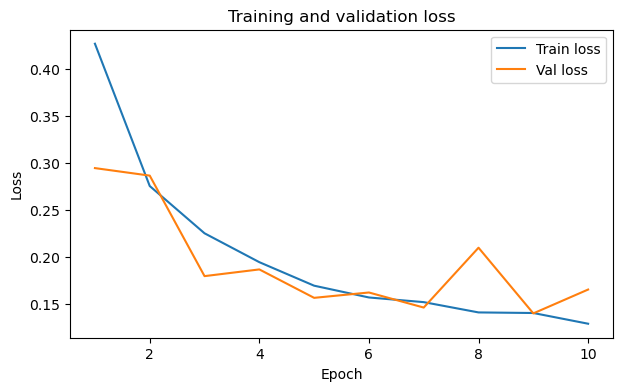

In [ ]:
# Plot loss for best overall experiment
plt.figure(figsize=(7, 4))
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["train_loss"], label="Train loss")
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["val_loss"], label="Val loss")
plt.title(f"Loss: {best_overall_config}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("plots/iou_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot IoU for best overall experiment
plt.figure(figsize=(7, 4))
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["train_iou"], label="Train IoU")
plt.plot(best_overall_history_df["epoch"], best_overall_history_df["val_iou"], label="Val IoU")
plt.title(f"IoU: {best_overall_config}")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.show()

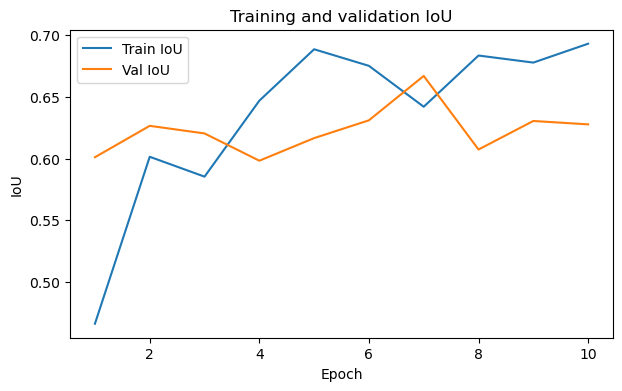

In [ ]:
# Load best overall model for visualization
best_model = build_model()
best_model.load_state_dict(torch.load(best_overall_path, map_location=device))
best_model.eval()

print(f"Loaded best overall model from: {best_overall_path}")

## 12. Qualitative predictions

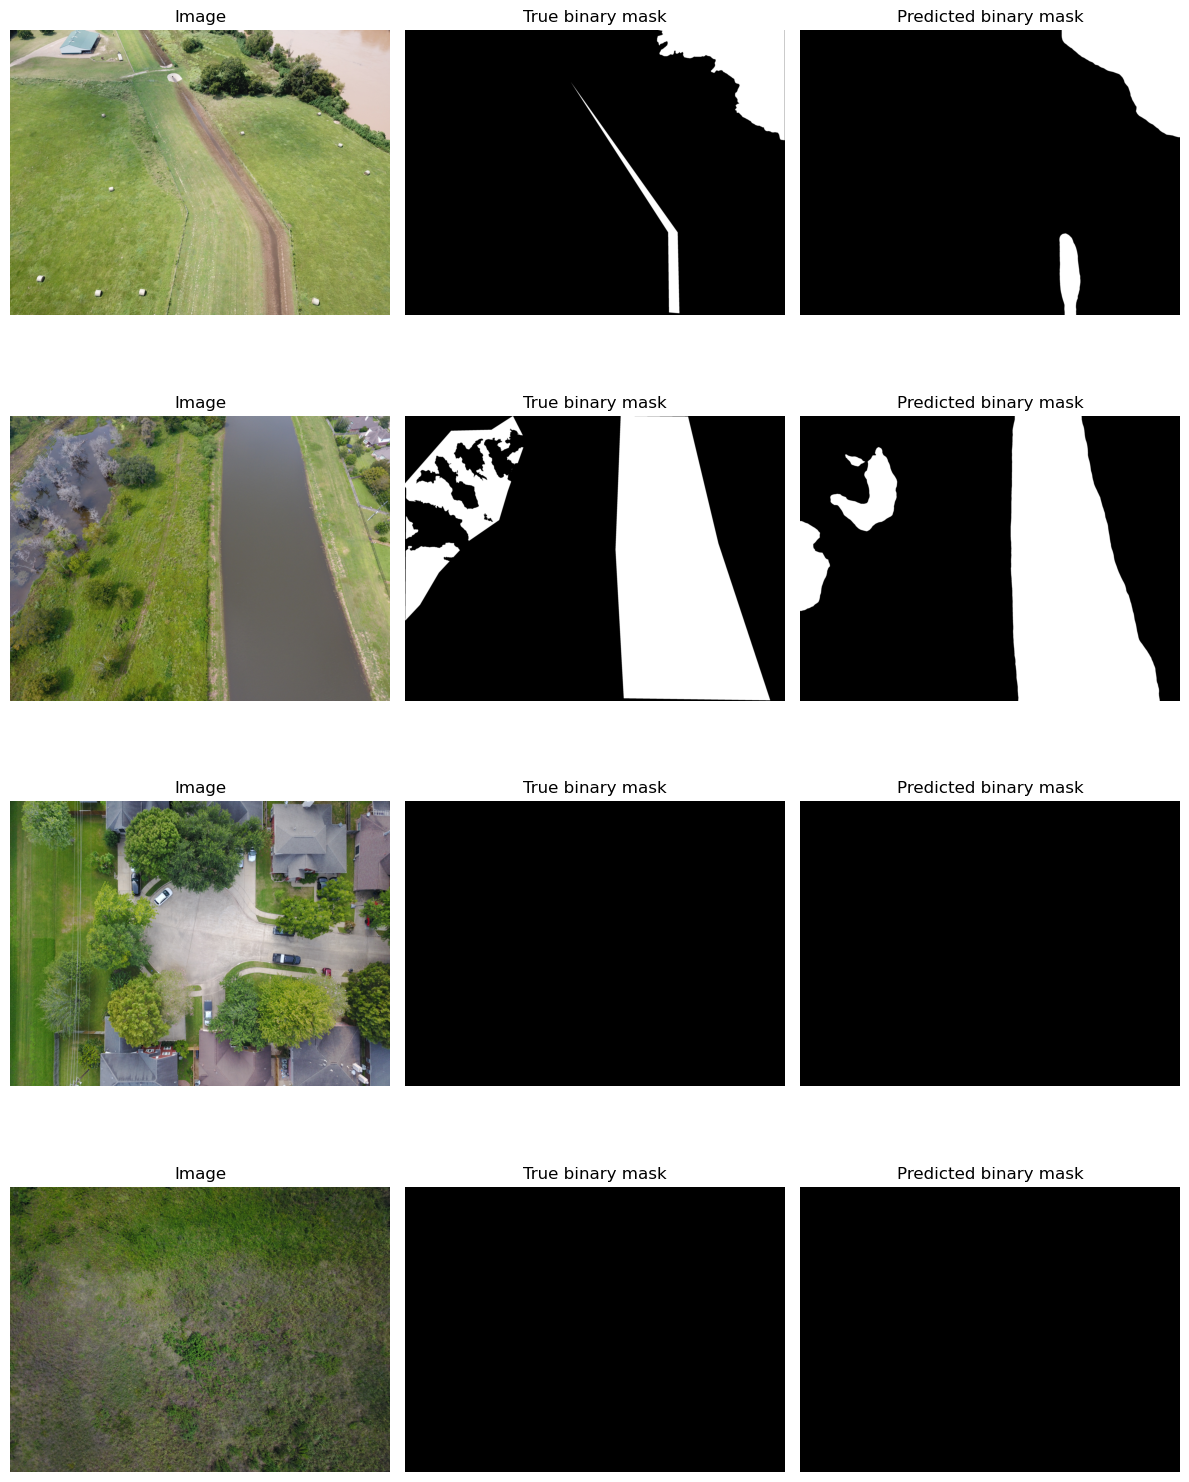

In [ ]:
def predict_mask(model, image_path, processor, threshold=None):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        upsampled_logits = nn.functional.interpolate(
            logits,
            size=image.size[::-1],
            mode="bilinear",
            align_corners=False
        )
        probs = torch.softmax(upsampled_logits, dim=1)
        pred = probs.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

    return image, pred


def visualize_predictions_with_truth(model, dataframe, processor, n=4):
    subset = dataframe.sample(min(n, len(dataframe)), random_state=7)
    fig, axes = plt.subplots(len(subset), 3, figsize=(12, 4 * len(subset)))
    if len(subset) == 1:
        axes = np.expand_dims(axes, axis=0)

    for ax_row, (_, row) in zip(axes, subset.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        true_mask = multiclass_to_binary(load_mask(row["mask_path"]))
        _, pred_mask = predict_mask(model, row["image_path"], processor)

        ax_row[0].imshow(image)
        ax_row[0].set_title("Image")
        ax_row[1].imshow(true_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[1].set_title("True binary mask")
        ax_row[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
        ax_row[2].set_title("Predicted binary mask")

        for ax in ax_row:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions_with_truth(best_model, val_df, processor, n=4)

## 13. Optional: K-fold cross-validation note

Your project document mentions **5-fold cross-validation**. For segmentation on datasets that already provide `train/val/test` splits, a common approach is:

1. keep the original `test` set untouched for final reporting
2. perform 5-fold CV only within the training portion
3. select hyperparameters using the validation folds
4. retrain on full training data
5. evaluate once on the held-out test set

That is more computationally expensive, so this notebook implements the main train/val/test pipeline first.

## 14. Suggested report-ready interpretation prompts

After training, summarize results around:
- whether SegFormer improves flood localization on complex scenes
- whether recall is strong enough for disaster assessment settings
- whether class imbalance causes overprediction of non-flood regions
- whether IoU/F1 support the claim that the model accurately identifies flooded regions

You can then compare this notebook's results against your U-Net and DeepLabV3+ runs.